# PCA Global vs. Local Test — Reproducing Bluck et al. (2020) Figure 11

This notebook reproduces the principal component analysis (PCA) described in **Section 4.3** of Bluck et al. (2020, MNRAS 492, 96), applied to our own simulation data. The analysis is run separately for four galaxy samples: **all centrals**, **all satellites**, **low-mass satellites**, and **high-mass satellites**.

---

## Scientific motivation

The RF analysis (Section 4.2 of Bluck+2020) establishes that *quenching* is governed by global (galaxy-wide) parameters, whereas *star formation rates* in star-forming regions are governed by local (spatially resolved) parameters. The PCA test provides an independent, machine-learning-free confirmation of this conclusion.

---

## What the analysis does — step by step

### 1. Define two parameter sets

We split our features into:

- **Local parameters** — measured at the level of each annular bin (i.e. spatially resolved, one value per annulus per galaxy):
  - `avg_s_mass`: stellar mass surface density of the annulus
  - `bin_radii`: galactocentric radius of the annulus
  - Note: `avg_SFR` is deliberately **excluded** because it is trivially connected to star formation.

- **Global parameters** — a single number per galaxy (broadcast to every annulus):
  - `s_mass`: total stellar mass of the galaxy
  - `BHMass`: black hole mass
  - `bulge`: bulge-to-total mass ratio
  - `Mhalo`: group halo mass
  - `overdens`: local galaxy overdensity

### 2. Standardise each set

Following Bluck+2020 eq. (section 4.3): subtract the mean and divide by the standard deviation for each parameter. This converts everything to a dimensionless, scale-free form so that parameters with very different units and ranges contribute equally to the PCA.

### 3. Run PCA on each set independently

PCA finds the linear combination of the input variables that captures the **maximum variance** in the data. We take only the **first principal component** (PC1) from each set:

- `PC1(local)`: a single number summarising the local physical conditions of each annulus
- `PC1(global)`: a single number summarising the global properties of the host galaxy

These are 'hyper-parameters' — compressed representations of each parameter group.

### 4. Make two diagnostic plots (reproducing Figure 11)

Plot `PC1(global)` (y-axis) vs `PC1(local)` (x-axis), using hexagonal bins:

- **Left panel (quenching)**: colour-coded by the **fraction of quenched annuli** (`quenching_vector == 1`) in each hex bin. If quenching is primarily a global process, the colour gradient should run **vertically** (along the y / global axis).
- **Right panel (star formation)**: restricted to star-forming annuli only (`quenching_vector == 0`), colour-coded by **mean SFR** (`avg_SFR`). If star formation is primarily a local process, the colour gradient should run **horizontally** (along the x / local axis).

### 5. Compute the 'quenching axis' angles θ_Q and θ_SF

To quantify the visual impression, we compute two angles (Bluck+2020, equations 16–17) using **partial Spearman rank correlation coefficients (PCC)**.

The PCC between variables A and B at fixed C is:

$$\rho_{AB,C} = \frac{\rho_{AB} - \rho_{AC} \cdot \rho_{BC}}{\sqrt{1 - \rho_{AC}^2} \sqrt{1 - \rho_{BC}^2}}$$

where $\rho$ denotes the Spearman rank correlation. Using this we compute:

$$\theta_Q = \arctan\!\left(\frac{\rho_{Y,f_{QS},X}}{\rho_{X,f_{QS},Y}}\right) \qquad \theta_{SF} = \arctan\!\left(\frac{\rho_{Y,\Sigma_{SFR},X}}{\rho_{X,\Sigma_{SFR},Y}}\right)$$

where X = PC1(local) and Y = PC1(global).

- **θ = 0°**: the quantity of interest (quenched fraction or SFR) depends entirely on the **global** (y-axis) parameter → quenching/SF is a global process.
- **θ = 90°**: it depends entirely on the **local** (x-axis) parameter → quenching/SF is a local process.
- **θ = 45°**: equal dependence on both.

Errors on θ are estimated from a **Monte Carlo simulation**: we add Gaussian noise at the level of each parameter's standard deviation, recompute, and take the dispersion.

---

## Feature mapping from our dataset

| Role | Column(s) |
|------|----------|
| Local features (PCA input) | `avg_s_mass`, `bin_radii` |
| Global features (PCA input) | `s_mass`, `BHMass`, `bulge`, `Mhalo`, `overdens` |
| Quenching label | `quenching_vector` (1 = quenched, 0 = star-forming) |
| SFR (right panel colour) | `avg_SFR` |
| Galaxy identifier | `subID` |


---
## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

print('All imports successful.')

All imports successful.


---
## 1. Load data

We load the four galaxy samples. Each parquet file already contains the correct population (centrals, all satellites, low-mass satellites, high-mass satellites), so no further splitting on mass is needed.

In [2]:
# ── Update these paths to match your directory layout ──────────────────────
low_mass_central_df  = pd.read_parquet('low_mass_central_df_annuli_revised.parquet')
high_mass_central_df = pd.read_parquet('high_mass_central_df_annuli_revised.parquet')
low_mass_sat_df      = pd.read_parquet('low_mass_satellite_df_annuli_revised.parquet')
high_mass_sat_df     = pd.read_parquet('high_mass_satellite_df_annuli_revised.parquet')
# ───────────────────────────────────────────────────────────────────────────

# Combine the two central sub-samples into a single 'all centrals' dataframe.
all_centrals_df = pd.concat([low_mass_central_df, high_mass_central_df],
                             ignore_index=True)

# Combine the two satellite sub-samples into a single 'all satellites' dataframe.
all_satellites_df = pd.concat([low_mass_sat_df, high_mass_sat_df],
                               ignore_index=True)

# Gather all four samples into a dict for easy looping later.
# Keys become subplot/figure titles.
samples = {
    'All Centrals'       : all_centrals_df,
    'All Satellites'     : all_satellites_df,
    'Low-Mass Satellites': low_mass_sat_df,
    'High-Mass Satellites': high_mass_sat_df,
}

for name, df in samples.items():
    print(f'{name}: {len(df):,} annuli, {df["subID"].nunique():,} galaxies')

All Centrals: 48,576 annuli, 4,605 galaxies
All Satellites: 14,506 annuli, 1,593 galaxies
Low-Mass Satellites: 5,831 annuli, 825 galaxies
High-Mass Satellites: 8,675 annuli, 768 galaxies


All Centrals: 50/48576 annuli with BHMass=0 (0.1%)
All Satellites: 598/14506 annuli with BHMass=0 (4.1%)
Low-Mass Satellites: 541/5831 annuli with BHMass=0 (9.3%)
High-Mass Satellites: 57/8675 annuli with BHMass=0 (0.7%)


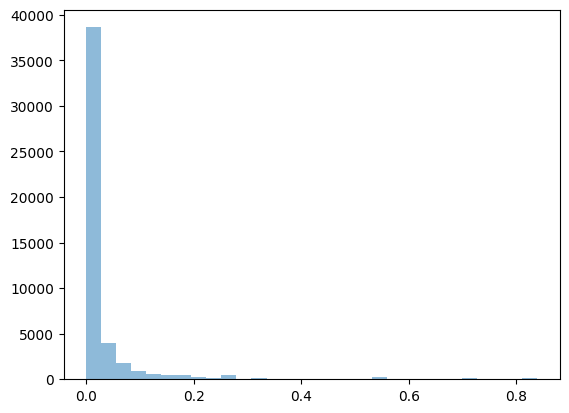

In [3]:
plt.hist(all_centrals_df['BHMass'], bins=30, alpha=0.5, label='Centrals')
for name, df in samples.items():
    n_zero = (df['BHMass'] == 0).sum()
    n_total = len(df)
    print(f"{name}: {n_zero}/{n_total} annuli with BHMass=0 "
          f"({n_zero/n_total*100:.1f}%)")

In [4]:
# ============================================================
# UNIT CONVERSIONS AND TRANSFORMATIONS
# ============================================================
# This cell should be run immediately after loading the data
# and before any PCA or other analysis.
#
# For each column, document:
#   1. The native units/definition as output by the simulation pipeline
#   2. The target units/definition for analysis
#   3. The transform applied and the scientific justification
#
# General principle: all parameters should be in log units where
# the underlying distribution is log-normal (masses, densities),
# and on a linear scale where the distribution is approximately
# normal or physically bounded (e.g. ratios in [0,1]).
# This ensures PCA variance is physically meaningful rather than
# dominated by the tail of a skewed distribution.
# ============================================================

def prepare_features(df):
    """
    Apply unit conversions and transforms to a galaxy dataframe.
    Returns a new dataframe with transformed columns, leaving the
    original dataframe unchanged.
    
    Fill in each block below with the correct transform for your data.
    """
    out = df.copy()

    # ── s_mass ──────────────────────────────────────────────────────────
    # Native units : 10^10 M_sun
    # Target       : log10(M_sun)
    # Transform    : out['s_mass'] = np.log10(out['s_mass']) + 10
    # Justification: Stellar mass is log-normally distributed
    out['s_mass'] = np.log10(out['s_mass']) + 10

    # ── BHMass ──────────────────────────────────────────────────────────
    # Native units : 10^10 M_sun
    # Target       : log10(M_sun)
    # Transform    : out['BHMass'] = np.log10(out['BHMass']) + 10
    # Note         : Seed-mass pile-up at low values is real simulation
    #                physics and should be retained, not removed.
    min_nonzero = out['BHMass'][out['BHMass'] > 0].min()
    out['BHMass'] = out['BHMass'].replace(0, min_nonzero / 2)
    out['BHMass'] = np.log10(out['BHMass']) + 10
    #out['BHMass'] = np.log10(out['BHMass']) + 10

    # ── bulge ────────────────────────────────────────────────────────────
    # Native units : Bulge-to-total stellar mass ratio, should be in [0, 1]
    # Current issue: Contains negative values — NaN imputation in pipeline
    #                is flawed and must be fixed before this column is used.
    # Action       : TODO — fix upstream NaN handling, then decide on transform.
    #                Until fixed, recommend excluding from GLOBAL_FEATURES.
    # out['bulge'] = ...

    # ── Mhalo ────────────────────────────────────────────────────────────
    # Native units : 10^10 M_sun
    # Target       : log10(M_sun)
    # Transform    : out['Mhalo'] = np.log10(out['Mhalo']) + 10
    # Justification: Halo mass is log-normally distributed
    out['Mhalo'] = np.log10(out['Mhalo']) + 10

    # ── overdens ─────────────────────────────────────────────────────────
    # Native units : N/A
    #                If (rho - rho_mean) / rho_mean, values near -1 are voids
    #                and a log(1 + overdens) transform is standard.
    #                If a raw count or ratio, log10 may be more appropriate.
    # Current issue: Spans ~8 orders of magnitude; extreme outliers dominate
    #                PCA variance on a linear scale.
    # Transform    : out['overdens'] = np.log10(1 + out['overdens'])
    # Justification: Standard transform for overdensity data to reduce skewness
    out['overdens'] = np.log10(1 + out['overdens'])

    # ── avg_s_mass (local stellar mass surface density) ──────────────────
    # Native units :  log10(M_sun / kpc^2)
    # Transform    : None
    # out['avg_s_mass'] = ...

    # ── bin_radii ────────────────────────────────────────────────────────
    # Native units : R/Re
    # Transform    : None
    # out['bin_radii'] = ...

    # ── avg_SFR (used only as colour-bar variable, not PCA input) ────────
    # Native units : log10(M_sun / yr / kpc^2)
    # Transform    : None
    # out['avg_SFR'] = ...

    return out


# Apply transforms to all four samples before analysis.
# Replace the originals so the rest of the notebook uses clean data.
low_mass_central_df   = prepare_features(low_mass_central_df)
high_mass_central_df  = prepare_features(high_mass_central_df)
low_mass_sat_df       = prepare_features(low_mass_sat_df)
high_mass_sat_df      = prepare_features(high_mass_sat_df)

# Rebuild the combined samples after transforming the sub-samples.
all_centrals_df  = pd.concat([low_mass_central_df, high_mass_central_df],
                              ignore_index=True)
all_satellites_df = pd.concat([low_mass_sat_df, high_mass_sat_df],
                               ignore_index=True)

samples = {
    'All Centrals'        : all_centrals_df,
    'All Satellites'      : all_satellites_df,
    'Low-Mass Satellites' : low_mass_sat_df,
    'High-Mass Satellites': high_mass_sat_df,
}



---
## 2. Define local and global parameter sets

We follow Bluck+2020 Section 4.3 exactly. `avg_SFR` is **not** included as a local feature because it is trivially connected to star formation — including it would conflate the predictor with the target variable.

In [5]:
# Local (spatially resolved) parameters — one value per annulus.
# avg_SFR is deliberately excluded (trivially connected to star formation).
LOCAL_FEATURES = ['avg_s_mass', 'bin_radii']

# Global (galaxy-wide) parameters — one value per galaxy, broadcast to all
# annuli of that galaxy.  These are NOT trivially connected to star formation.
GLOBAL_FEATURES = ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge'] #removed bulge due to NaN issues

# Target columns (NOT PCA inputs — only used for colouring the hex plots).
QUENCH_COL = 'quenching_vector'   # 1 = quenched, 0 = star-forming
SFR_COL    = 'avg_SFR'            # log10 SFR of each annular bin
ID_COL     = 'subID'              # galaxy identifier

print('Local features :', LOCAL_FEATURES)
print('Global features:', GLOBAL_FEATURES)

Local features : ['avg_s_mass', 'bin_radii']
Global features: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']


In [6]:
print('Transforms applied. Quick sanity check on global features:')
for col in GLOBAL_FEATURES:
    vals = all_centrals_df[col].dropna()
    print(f'  {col:15s}  min={vals.min():.3f}  max={vals.max():.3f}  '
          f'std={vals.std():.3f}  n_unique={vals.nunique()}')

Transforms applied. Quick sanity check on global features:
  s_mass           min=9.028  max=12.569  std=0.781  n_unique=4600
  BHMass           min=5.602  max=9.923  std=0.863  n_unique=4596
  Mhalo            min=10.419  max=14.590  std=0.760  n_unique=4599
  overdens         min=-1.278  max=7.240  std=1.111  n_unique=4546
  bulge            min=-1.598  max=1.522  std=0.533  n_unique=3684


---
## 3. PCA helper function

This function takes a dataframe and a list of column names, standardises them (zero mean, unit variance — exactly as in Bluck+2020 Section 4.3), runs PCA, and returns the first principal component scores for every row.

**Why standardise?**  
PCA is sensitive to the scale of variables. Without standardisation, a parameter with a large numerical range (e.g. stellar mass in solar masses) would dominate the first PC simply by virtue of its magnitude, not its physical importance. Standardising puts every parameter on equal footing.

In [7]:
def compute_pc1(df, feature_cols):
    """
    Standardise the selected columns of df and return the scores along the
    first principal component (PC1).

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    feature_cols : list of str
        Column names to include in the PCA.

    Returns
    -------
    pc1_scores : np.ndarray, shape (n_rows,)
        Each element is the projection of that row onto PC1.
    explained_variance_ratio : float
        Fraction of total variance captured by PC1.
    loadings : pd.Series
        The PC1 eigenvector (loadings for each input feature), useful for
        interpreting what PC1 represents physically.
    """
    X = df[feature_cols].values  # shape: (n_annuli, n_features)

    # Step 1: Standardise — subtract mean, divide by std.
    # This is exactly what Bluck+2020 Section 4.3 prescribes:
    # "we rescale each parameter by subtracting off the mean value,
    #  and normalising by the standard deviation."
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Step 2: PCA — find the direction of maximum variance.
    pca = PCA(n_components=1)
    pc1_scores = pca.fit_transform(X_scaled).ravel()  # shape: (n_annuli,)

    explained_var = pca.explained_variance_ratio_[0]
    loadings = pd.Series(pca.components_[0], index=feature_cols)

    return pc1_scores, explained_var, loadings

---
## 4. Partial Spearman correlation helper

The **partial correlation coefficient (PCC)** measures the strength of the correlation between two variables A and B *after removing the shared linear influence of a third variable C*. We use the Spearman (rank-based) version, which is more robust to non-linearity than the Pearson version.

Bluck+2020 equation (15):

$$\rho_{AB,C} = \frac{\rho_{AB} - \rho_{AC} \cdot \rho_{BC}}{\sqrt{(1 - \rho_{AC}^2)(1 - \rho_{BC}^2)}}$$

In [8]:
def spearman_r(a, b):
    """Spearman rank correlation coefficient between arrays a and b."""
    return spearmanr(a, b).statistic


def partial_spearman(a, b, c):
    """
    Partial Spearman correlation between a and b, controlling for c.
    Implements Bluck+2020 equation (15).

    Parameters
    ----------
    a, b, c : array-like
        The three variables.  'c' is the variable being controlled for.

    Returns
    -------
    float
        Partial Spearman correlation rho_{ab, c}.
    """
    rho_ab = spearman_r(a, b)
    rho_ac = spearman_r(a, c)
    rho_bc = spearman_r(b, c)

    numerator   = rho_ab - rho_ac * rho_bc
    denominator = np.sqrt((1 - rho_ac**2) * (1 - rho_bc**2))

    # Guard against division by zero (perfect collinearity).
    if denominator == 0:
        return np.nan
    return numerator / denominator


def compute_theta(pc1_local, pc1_global, colour_var):
    """
    Compute the 'quenching axis' angle θ (in degrees) as defined in
    Bluck+2020 equations (16) and (17).

    θ is measured clockwise from the vertical (global / y-axis).
    It tells us which axis — local (x) or global (y) — most strongly
    drives the colour variable:

        θ = 0°  → colour_var correlates entirely with PC1(global)
        θ = 90° → colour_var correlates entirely with PC1(local)
        θ = 45° → equal correlation with both axes

    Parameters
    ----------
    pc1_local  : array-like   — scores along PC1(local),  the x-axis
    pc1_global : array-like   — scores along PC1(global), the y-axis
    colour_var : array-like   — the variable colouring the hex bins
                                (e.g. quenched fraction or mean SFR)

    Returns
    -------
    theta_deg : float
        The angle in degrees.
    """
    # Partial correlation of colour_var with PC1(global) [y-axis],
    # controlling for PC1(local) [x-axis].
    rho_Y_fQ_X = partial_spearman(pc1_global, colour_var, pc1_local)

    # Partial correlation of colour_var with PC1(local) [x-axis],
    # controlling for PC1(global) [y-axis].
    rho_X_fQ_Y = partial_spearman(pc1_local, colour_var, pc1_global)

    # Equation (16) / (17): θ = arctan(rho_Y / rho_X)
    theta_rad = np.arctan2(rho_X_fQ_Y, rho_Y_fQ_X)    
    return np.degrees(theta_rad)

---
## 5. Monte Carlo error estimation for θ

Bluck+2020 compute 1σ errors on θ by perturbing each parameter within its measurement uncertainty and recomputing the angle. We approximate this by adding Gaussian noise at the level of each parameter's standard deviation across the sample, repeating `n_mc` times, and taking the standard deviation of the resulting θ values.

In [9]:
def compute_theta_mc_error(pc1_local, pc1_global, colour_var,
                           n_mc=100, noise_scale=0.05, seed=42):
    """
    Estimate the 1σ uncertainty on θ via Monte Carlo perturbation.

    In each MC iteration we add small Gaussian noise (scaled to
    `noise_scale` × the standard deviation of each array) to
    pc1_local, pc1_global, and colour_var, then recompute θ.
    The reported error is the standard deviation across all MC draws.

    Parameters
    ----------
    pc1_local, pc1_global, colour_var : array-like
        As for compute_theta().
    n_mc : int
        Number of Monte Carlo iterations (default 100).
    noise_scale : float
        Noise amplitude as a fraction of each array's standard deviation.
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    theta_err : float
        1σ error on θ in degrees.
    """
    rng = np.random.default_rng(seed)
    thetas = []

    x = np.asarray(pc1_local,  dtype=float)
    y = np.asarray(pc1_global, dtype=float)
    z = np.asarray(colour_var, dtype=float)

    # Noise amplitude = noise_scale × std of each variable.
    sx = noise_scale * x.std()
    sy = noise_scale * y.std()
    sz = noise_scale * z.std()

    for _ in range(n_mc):
        x_p = x + rng.normal(0, sx, size=x.shape)
        y_p = y + rng.normal(0, sy, size=y.shape)
        z_p = z + rng.normal(0, sz, size=z.shape)
        thetas.append(compute_theta(x_p, y_p, z_p))

    return np.std(thetas)

---
## 6. Hex-bin colour helper

The two panels use hexagonal binning of the PC1(local)–PC1(global) plane, coloured by a statistic computed within each bin (fraction quenched, or mean SFR). This helper replicates the style of Bluck+2020 Figure 11.

In [10]:
# ============================================================
# PLOTTING HELPERS — density contours and hexbin
# ============================================================
# Imports your density_contour function and replaces the previous
# hexbin_stat helper, which used a second ax.hexbin() call to draw
# contours (incorrect). Contours are now drawn using KDE via
# density_contour() from density_contours.py.
# ============================================================

import sys
sys.path.append('.')  # ensures density_contours.py is found in the working directory
from density_contours import density_contour


def hexbin_stat(ax, x, y, z, gridsize=20, cmap='RdYlBu_r',
                vmin=None, vmax=None, min_count=11,
                contour_color='black', contour_levels=5,
                contour_kwargs=None):
    """
    Create a hexagonal binning plot coloured by the mean of z within
    each bin, then overlay KDE density contours using density_contour().

    For a binary z variable (0/1 quenching_vector), the mean of z within
    each bin is the fraction of quenched annuli — exactly what we want
    for the left panel of Figure 11.

    For a continuous z variable (avg_SFR), the mean is the mean SFR —
    exactly what we want for the right panel.

    Parameters
    ----------
    ax             : matplotlib Axes
    x, y           : array-like — PC1(local) and PC1(global) scores
    z              : array-like — values to aggregate (quench flag or SFR)
    gridsize       : int   — number of hexagons along the x-axis
    cmap           : str   — colormap for the hexbin fill
    vmin, vmax     : float — colour scale limits (optional)
    min_count      : int   — minimum points per hex bin to render
    contour_color  : str   — colour of the KDE contour lines
    contour_levels : int   — number of contour levels to draw
    contour_kwargs : dict  — any extra kwargs passed to density_contour()
                             (e.g. linewidths, linestyles, alpha)

    Returns
    -------
    hb : PolyCollection returned by ax.hexbin, used to attach a colorbar
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    z = np.asarray(z, dtype=float)

    # ── Hexbin coloured by mean(z) ────────────────────────────────────────
    # For a 0/1 z variable, mean = quenched fraction. For continuous z,
    # mean = mean value. reduce_C_function=np.mean handles both correctly.
    hb = ax.hexbin(x, y, C=z, reduce_C_function=np.mean,
                   gridsize=gridsize, mincnt=min_count,
                   cmap=cmap, vmin=vmin, vmax=vmax,
                   linewidths=0.2)

    # ── KDE density contours ──────────────────────────────────────────────
    # density_contour() fits a Gaussian KDE to (x, y) and draws contour
    # lines at the requested levels. This is the correct approach — the
    # previous version incorrectly used a second ax.hexbin() call for
    # contours, which does not produce smooth KDE-based contour lines.
    ck = {'colors': contour_color, 'levels': contour_levels,
          'linewidths': 1.2, 'alpha': 0.7}
    if contour_kwargs is not None:
        ck.update(contour_kwargs)

    density_contour(x, y, axis=ax, **ck)

    return hb

---
## 7. Arrow helper

Bluck+2020 Figure 11 draws a thick arrow through the origin pointing in the direction of θ (clockwise from vertical). This replicates that style.

In [11]:
def draw_theta_arrow(ax, theta_deg, length=2.5, color='black', lw=3):
    """
    Draw a double-headed arrow through the origin pointing in the
    direction of theta_deg, measured clockwise from the vertical (y-axis),
    following the Bluck+2020 convention.

        θ = 0°   → points straight up   (global dominates)
        θ = 90°  → points right          (local dominates)
        θ = 180° → points straight down
        θ = -90° → points left
    """
    # theta_deg is clockwise from vertical.
    # Convert to standard anticlockwise-from-x-axis for numpy trig:
    #   phi = 90° - theta_deg
    phi = np.radians(90.0 - theta_deg)
    dx = length * np.cos(phi)
    dy = length * np.sin(phi)

    ax.annotate('', xy=(dx, dy), xytext=(-dx, -dy),
                arrowprops=dict(arrowstyle='->', color=color, lw=lw))

---
## 8. Main analysis function

This function wraps the entire pipeline for a single galaxy sample:
1. Compute PC1(local) and PC1(global)
2. Compute θ_Q and θ_SF with MC errors
3. Produce the two-panel Figure 11 reproduction

In [12]:
def run_pca_analysis(df, sample_name,
                     local_features=LOCAL_FEATURES,
                     global_features=GLOBAL_FEATURES,
                     quench_col=QUENCH_COL,
                     sfr_col=SFR_COL,
                     n_mc=100,
                     gridsize=30,
                     figsize=(13, 5.5)):
    """
    Run the full PCA global-vs-local analysis for one galaxy sample and
    produce a two-panel figure reproducing Bluck+2020 Figure 11.

    Parameters
    ----------
    df           : pd.DataFrame — the galaxy sample
    sample_name  : str          — used in the figure title
    local_features, global_features : lists of column names
    quench_col   : str — binary quenching label column
    sfr_col      : str — SFR column (for the right panel)
    n_mc         : int — Monte Carlo iterations for θ errors
    gridsize     : int — hexbin grid density
    figsize      : tuple

    Returns
    -------
    results : dict
        Contains pc1_local, pc1_global, theta_Q, theta_Q_err,
        theta_SF, theta_SF_err, and PCA loading information.
    """

    # ── 1. Drop any rows with NaN in the required columns ─────────────────
    needed_cols = local_features + global_features + [quench_col, sfr_col]
    df_clean = df[needed_cols].dropna()
    n_dropped = len(df) - len(df_clean)
    if n_dropped > 0:
        print(f'  [{sample_name}] Dropped {n_dropped:,} rows with NaN values.')

    # ── 2. Compute PC1 for each parameter group ────────────────────────────
    print(f'  [{sample_name}] Computing PC1(local) from: {local_features}')
    pc1_local,  ev_local,  load_local  = compute_pc1(df_clean, local_features)

    print(f'  [{sample_name}] Computing PC1(global) from: {global_features}')
    pc1_global, ev_global, load_global = compute_pc1(df_clean, global_features)

    print(f'  [{sample_name}] PC1(local)  explains {ev_local*100:.1f}% of local variance')
    print(f'  [{sample_name}] PC1(global) explains {ev_global*100:.1f}% of global variance')
    print(f'  [{sample_name}] PC1(local) loadings:\n{load_local.to_string()}')
    print(f'  [{sample_name}] PC1(global) loadings:\n{load_global.to_string()}')

    quench_vec = df_clean[quench_col].values.astype(float)
    sfr_vec    = df_clean[sfr_col].values.astype(float)

    # ── 3. Restrict to star-forming annuli for the SF panel ────────────────
    # The right panel of Fig. 11 shows only star-forming spaxels, colour-
    # coded by mean SFR.  We identify star-forming annuli as quench_vec == 0.
    sf_mask = (quench_vec == 0)
    pc1_local_sf  = pc1_local[sf_mask]
    pc1_global_sf = pc1_global[sf_mask]
    sfr_sf        = sfr_vec[sf_mask]

    print(f'  [{sample_name}] Star-forming annuli: {sf_mask.sum():,} / {len(sf_mask):,} '
          f'({sf_mask.mean()*100:.1f}%)')

    # ── 4. Compute θ_Q (quenching axis) ───────────────────────────────────
    # Input: ALL annuli; colour variable = binary quenching label.
    # Per Bluck+2020 eq. (16), we use the per-annulus quenching_vector
    # directly (equivalent to the binned quenched fraction in the limit
    # of small bins — using per-annulus values is more statistically robust).
    print(f'  [{sample_name}] Computing θ_Q ...')
    theta_Q     = compute_theta(pc1_local, pc1_global, quench_vec)
    theta_Q_err = compute_theta_mc_error(pc1_local, pc1_global, quench_vec,
                                         n_mc=n_mc)
    print(f'  [{sample_name}] θ_Q = {theta_Q:.1f}° ± {theta_Q_err:.1f}°')

    # ── 5. Compute θ_SF (star-formation axis) ─────────────────────────────
    # Input: STAR-FORMING annuli only; colour variable = SFR.
    print(f'  [{sample_name}] Computing θ_SF ...')
    theta_SF     = compute_theta(pc1_local_sf, pc1_global_sf, sfr_sf)
    theta_SF_err = compute_theta_mc_error(pc1_local_sf, pc1_global_sf, sfr_sf,
                                          n_mc=n_mc)
    print(f'  [{sample_name}] θ_SF = {theta_SF:.1f}° ± {theta_SF_err:.1f}°')

    # ── 6. Plot ────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle(f'PCA Global vs. Local — {sample_name}', fontsize=13,
                 fontweight='bold', y=1.01)

    # ── Panel A: Quenching (all annuli) ──────────────────────────────────
    ax = axes[0]

    # Hexbin coloured by quenched fraction (mean of 0/1 = fraction quenched).
    hb_q = hexbin_stat(ax, pc1_local, pc1_global, quench_vec,
                       
                       gridsize=gridsize, cmap='bwr',
                       vmin=0.0, vmax=1.0)
    
    fig2,ax2=plt.subplots(1,1)
    ax2.hist(pc1_local, bins=30, alpha=0.5, label=f'PC1(local) [SF annuli] - {sample_name}')
    ax2.hist(pc1_global, bins=30, alpha=0.5, label=f'PC1(global) [SF annuli] - {sample_name}')
    ax2.legend()
    fig2.show()
    # Add density contours using a separate hexbin call with no colour fill.
    # This replicates the black contour lines in Bluck+2020 Fig. 11.
    #ax.hexbin(pc1_local, pc1_global, gridsize=gridsize,
    #          mincnt=5, cmap='Greys', alpha=0.15, linewidths=0.5)

    cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
    cb_q.set_label(r'$f_{\rm QS}$  (quenched fraction)', fontsize=10)

    # Draw the θ_Q arrow.
    draw_theta_arrow(ax, theta_Q, length=2.0, color='black', lw=3)

    ax.set_xlabel(r'LOCAL:  $\rm PC_1(local)$', fontsize=11)
    ax.set_ylabel(r'GLOBAL:  $\rm PC_1(global)$', fontsize=11)
    ax.set_title(
        f'Quenching — All Annuli\n'
        r'$\theta_Q$ = ' + f'{theta_Q:.0f}(±{theta_Q_err:.0f})°',
        fontsize=10)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')

    # ── Panel B: Star formation (SF annuli only) ──────────────────────────
    ax = axes[1]

    hb_sf = hexbin_stat(ax, pc1_local_sf, pc1_global_sf, sfr_sf,
                        
                        gridsize=gridsize, cmap='gist_rainbow')

    # Density contours for the SF sub-sample.
    #ax.hexbin(pc1_local_sf, pc1_global_sf, gridsize=gridsize,
    #          mincnt=5, cmap='Greys', alpha=0.15, linewidths=0.5)

    cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)
    cb_sf.set_label(r'$\log(\Sigma_{\rm SFR})$  [mean]', fontsize=10)

    # Draw the θ_SF arrow.
    draw_theta_arrow(ax, theta_SF, length=2.0, color='black', lw=3)

    ax.set_xlabel(r'LOCAL:  $\rm PC_1(local)$', fontsize=11)
    ax.set_ylabel(r'GLOBAL:  $\rm PC_1(global)$', fontsize=11)
    ax.set_title(
        f'Star Formation — SF Annuli Only\n'
        r'$\theta_{\rm SF}$ = ' + f'{theta_SF:.0f}(±{theta_SF_err:.0f})°',
        fontsize=10)
    ax.axhline(0, color='grey', lw=0.5, ls='--')
    ax.axvline(0, color='grey', lw=0.5, ls='--')

    plt.tight_layout()
    plt.savefig(f'pca_fig11_{sample_name.replace(" ", "_")}.pdf',
                bbox_inches='tight', dpi=150)
    plt.show()
    print()

    # ── 7. Return results for further inspection ───────────────────────────
    return {
        'sample'         : sample_name,
        'pc1_local'      : pc1_local,
        'pc1_global'     : pc1_global,
        'quench_vec'     : quench_vec,
        'sfr_vec'        : sfr_vec,
        'ev_local'       : ev_local,
        'ev_global'      : ev_global,
        'load_local'     : load_local,
        'load_global'    : load_global,
        'theta_Q'        : theta_Q,
        'theta_Q_err'    : theta_Q_err,
        'theta_SF'       : theta_SF,
        'theta_SF_err'   : theta_SF_err,
    }

---
## 9. Run the analysis for all four samples

This cell loops over all four samples and produces one two-panel figure each, plus a summary table of θ angles at the end.


  Running: All Centrals
  [All Centrals] Computing PC1(local) from: ['avg_s_mass', 'bin_radii']
  [All Centrals] Computing PC1(global) from: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']
  [All Centrals] PC1(local)  explains 86.3% of local variance
  [All Centrals] PC1(global) explains 75.3% of global variance
  [All Centrals] PC1(local) loadings:
avg_s_mass   -0.707107
bin_radii     0.707107
  [All Centrals] PC1(global) loadings:
s_mass      0.496853
BHMass      0.492898
Mhalo       0.497832
overdens    0.363774
bulge       0.360583
  [All Centrals] Star-forming annuli: 32,953 / 48,576 (67.8%)
  [All Centrals] Computing θ_Q ...
  [All Centrals] θ_Q = -11.9° ± 0.7°
  [All Centrals] Computing θ_SF ...
  [All Centrals] θ_SF = -110.7° ± 0.0°


C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:107: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:133: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)


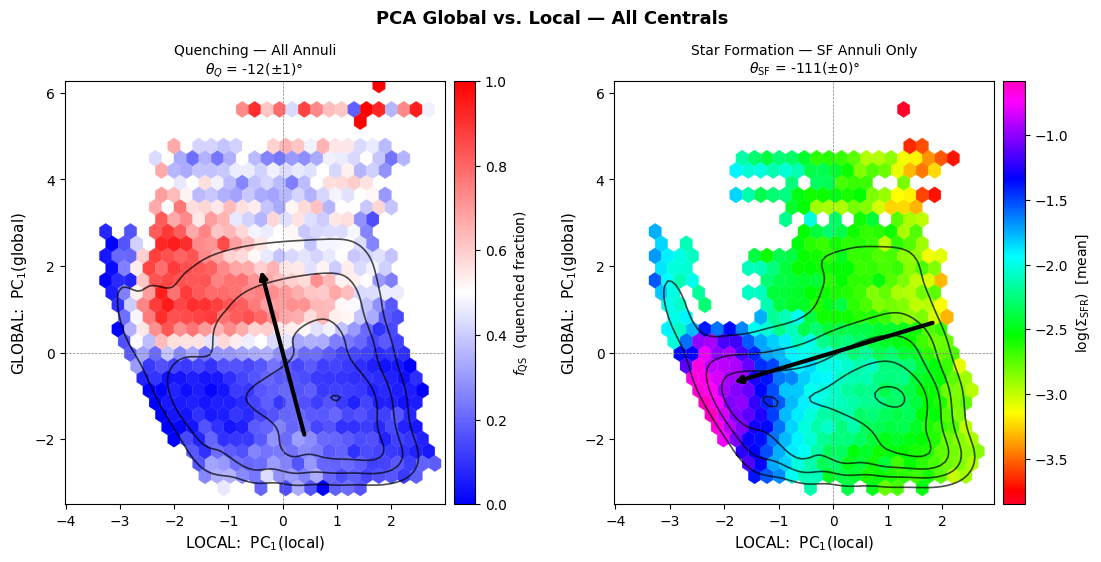

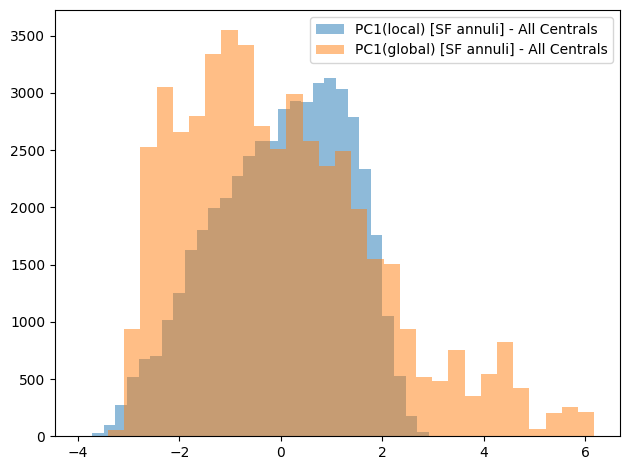



  Running: All Satellites
  [All Satellites] Computing PC1(local) from: ['avg_s_mass', 'bin_radii']
  [All Satellites] Computing PC1(global) from: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']
  [All Satellites] PC1(local)  explains 85.4% of local variance
  [All Satellites] PC1(global) explains 58.0% of global variance
  [All Satellites] PC1(local) loadings:
avg_s_mass    0.707107
bin_radii    -0.707107
  [All Satellites] PC1(global) loadings:
s_mass      0.522354
BHMass      0.496675
Mhalo       0.412446
overdens    0.404166
bulge       0.383404
  [All Satellites] Star-forming annuli: 8,146 / 14,506 (56.2%)
  [All Satellites] Computing θ_Q ...
  [All Satellites] θ_Q = 8.3° ± 1.0°
  [All Satellites] Computing θ_SF ...
  [All Satellites] θ_SF = 112.5° ± 0.1°


C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:107: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:133: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)


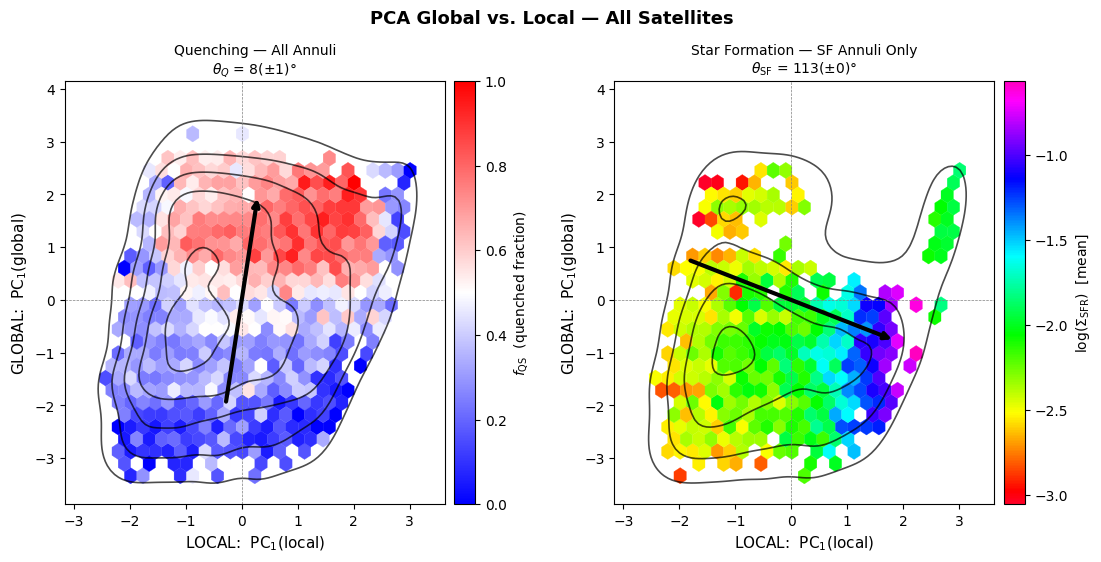

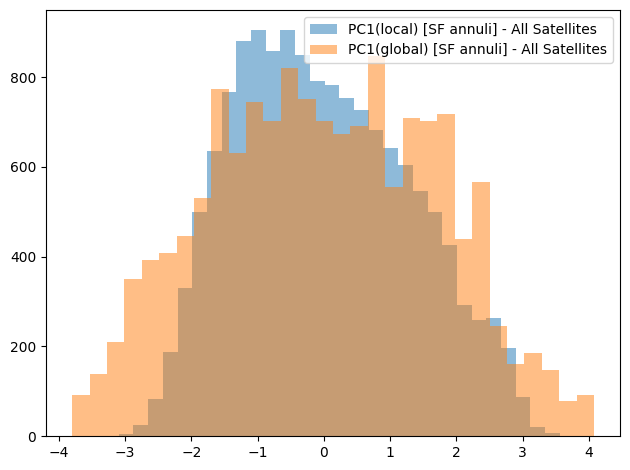



  Running: Low-Mass Satellites
  [Low-Mass Satellites] Computing PC1(local) from: ['avg_s_mass', 'bin_radii']
  [Low-Mass Satellites] Computing PC1(global) from: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']
  [Low-Mass Satellites] PC1(local)  explains 88.2% of local variance
  [Low-Mass Satellites] PC1(global) explains 36.2% of global variance
  [Low-Mass Satellites] PC1(local) loadings:
avg_s_mass    0.707107
bin_radii    -0.707107
  [Low-Mass Satellites] PC1(global) loadings:
s_mass      0.497631
BHMass      0.330670
Mhalo       0.554843
overdens    0.574846
bulge       0.068716
  [Low-Mass Satellites] Star-forming annuli: 3,964 / 5,831 (68.0%)
  [Low-Mass Satellites] Computing θ_Q ...
  [Low-Mass Satellites] θ_Q = -8.0° ± 2.8°
  [Low-Mass Satellites] Computing θ_SF ...
  [Low-Mass Satellites] θ_SF = 76.3° ± 0.1°


C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:107: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:133: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)


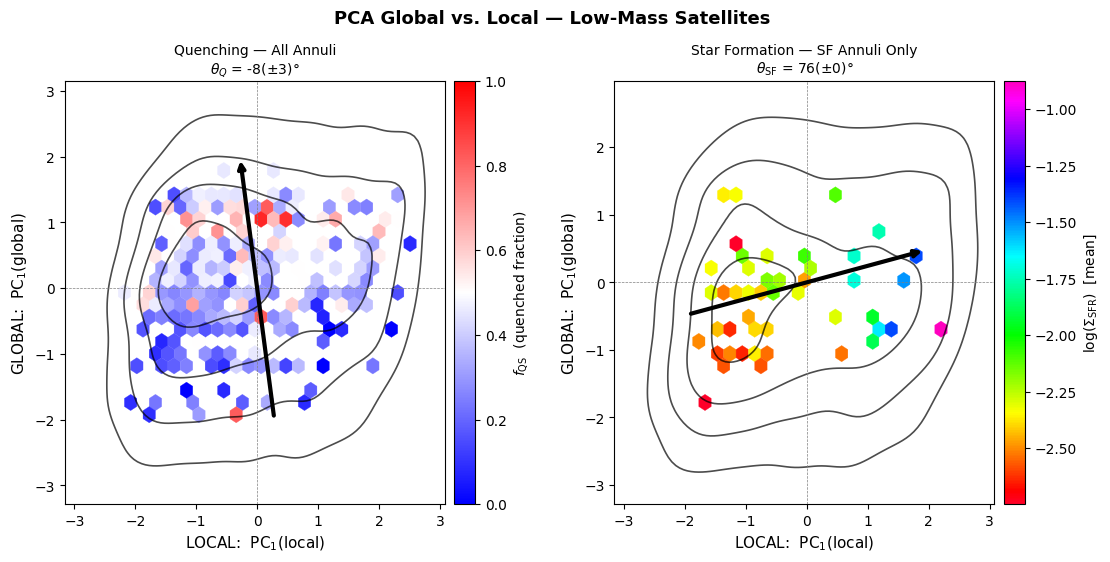

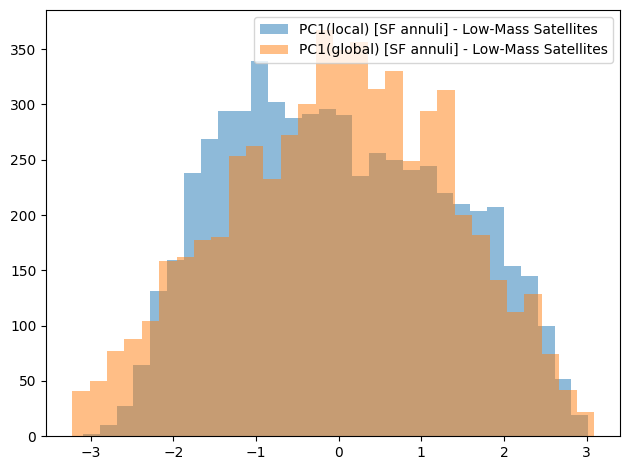



  Running: High-Mass Satellites
  [High-Mass Satellites] Computing PC1(local) from: ['avg_s_mass', 'bin_radii']
  [High-Mass Satellites] Computing PC1(global) from: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']
  [High-Mass Satellites] PC1(local)  explains 90.9% of local variance
  [High-Mass Satellites] PC1(global) explains 58.8% of global variance
  [High-Mass Satellites] PC1(local) loadings:
avg_s_mass    0.707107
bin_radii    -0.707107
  [High-Mass Satellites] PC1(global) loadings:
s_mass      0.513603
BHMass      0.514210
Mhalo       0.429864
overdens    0.418490
bulge       0.334488
  [High-Mass Satellites] Star-forming annuli: 4,182 / 8,675 (48.2%)
  [High-Mass Satellites] Computing θ_Q ...
  [High-Mass Satellites] θ_Q = 24.5° ± 1.7°
  [High-Mass Satellites] Computing θ_SF ...
  [High-Mass Satellites] θ_SF = 127.9° ± 0.1°


C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:107: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:133: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)


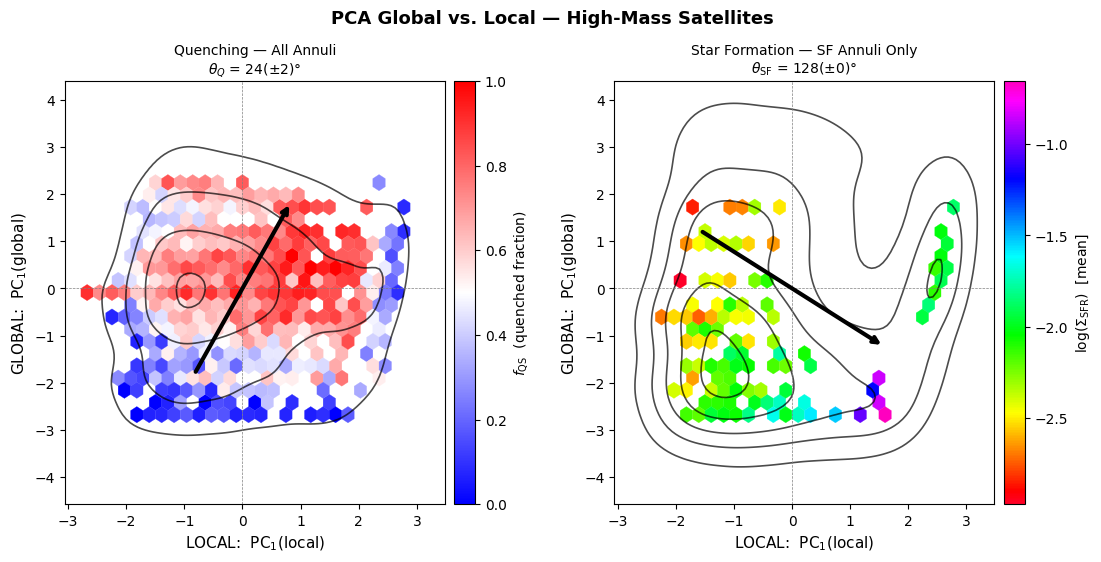

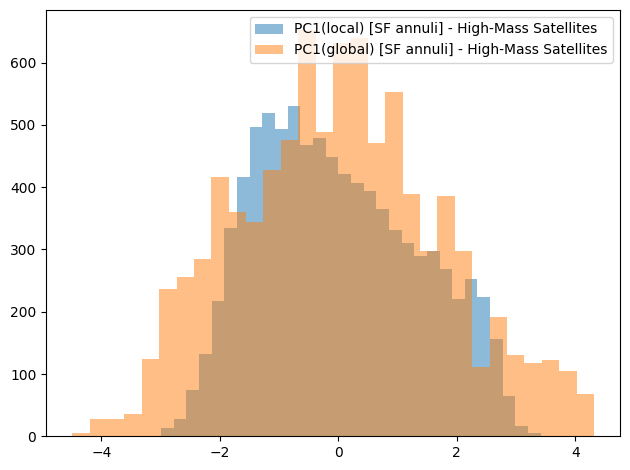

In [13]:
all_results = {}

for sample_name, df in samples.items():
    print(f'\n{'='*60}')
    print(f'  Running: {sample_name}')
    print(f'{'='*60}')
    results = run_pca_analysis(df, sample_name, n_mc=100)
    all_results[sample_name] = results
    


Full sample: 63,082 annuli, 6,198 galaxies
  [All Galaxies] Computing PC1(local) from: ['avg_s_mass', 'bin_radii']
  [All Galaxies] Computing PC1(global) from: ['s_mass', 'BHMass', 'Mhalo', 'overdens', 'bulge']
  [All Galaxies] PC1(local)  explains 86.0% of local variance
  [All Galaxies] PC1(global) explains 67.4% of global variance
  [All Galaxies] PC1(local) loadings:
avg_s_mass   -0.707107
bin_radii     0.707107
  [All Galaxies] PC1(global) loadings:
s_mass      0.503750
BHMass      0.491386
Mhalo       0.462650
overdens    0.389453
bulge       0.372904
  [All Galaxies] Star-forming annuli: 41,099 / 63,082 (65.2%)
  [All Galaxies] Computing θ_Q ...
  [All Galaxies] θ_Q = -10.8° ± 0.4°
  [All Galaxies] Computing θ_SF ...
  [All Galaxies] θ_SF = -110.7° ± 0.0°


C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:101: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig2.show()
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:107: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 3 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_q = plt.colorbar(hb_q, ax=ax, pad=0.02)
C:\Users\br.mcdonough\AppData\Local\Temp\ipykernel_37796\2631686880.py:133: UserWarning: Adding colorbar to a different Figure <Figure size 1300x550 with 4 Axes> than <Figure size 640x480 with 1 Axes> which fig.colorbar is called on.
  cb_sf = plt.colorbar(hb_sf, ax=ax, pad=0.02)


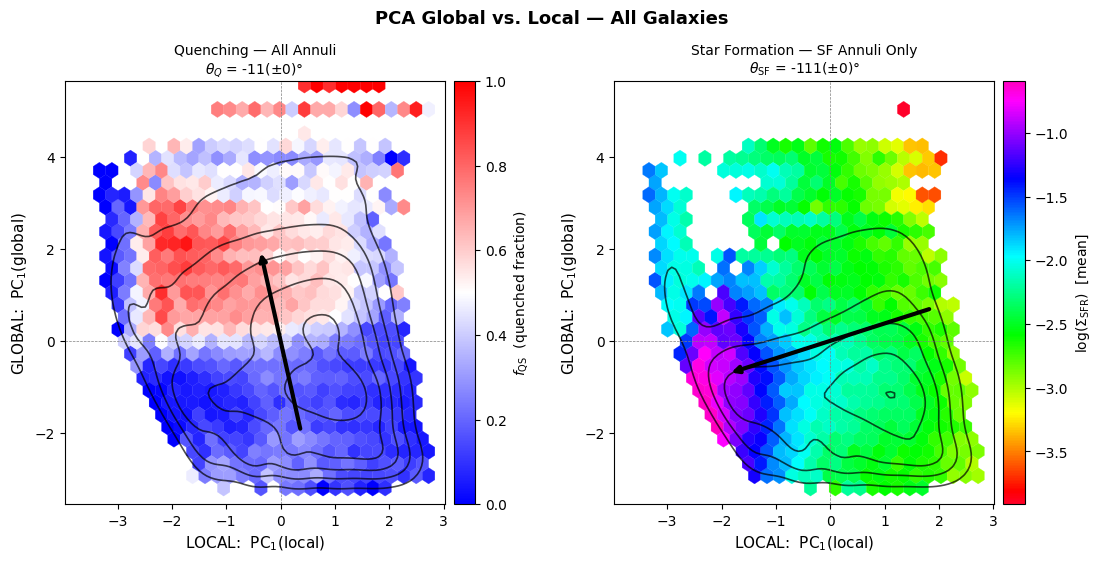

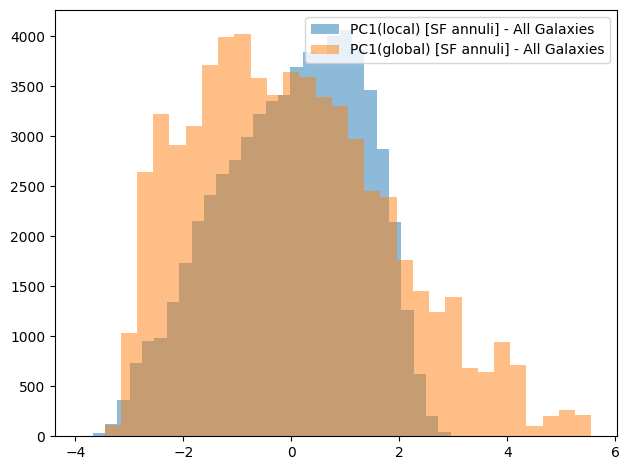

In [14]:
# ============================================================
# Run PCA analysis on the full combined sample
# (all centrals + all satellites)
# ============================================================
# This combines all four sub-samples into a single dataframe
# and runs the PCA analysis on the full galaxy population,
# without any central/satellite or mass distinction.
# This provides a global baseline to compare against the
# individual sub-sample results above.
# ============================================================

all_galaxies_df = pd.concat(
    [low_mass_central_df, high_mass_central_df,
     low_mass_sat_df,     high_mass_sat_df],
    ignore_index=True
)

print(f'Full sample: {len(all_galaxies_df):,} annuli, '
      f'{all_galaxies_df["subID"].nunique():,} galaxies')

results_all = run_pca_analysis(all_galaxies_df, 'All Galaxies', n_mc=100)
all_results['All Galaxies'] = results_all

---
## 10. Summary table

Collect the θ angles and PCA variance fractions across all samples for easy comparison.

**Interpretation guide:**
- θ_Q close to 0° → quenching is a **global** process (as found by Bluck+2020 for centrals)
- θ_SF close to 90° → star formation is a **local** process (as found by Bluck+2020)
- Large difference between θ_SF and (θ_Q + 180°) → star formation and quenching are **distinct** physical processes

In [15]:
rows = []
for name, res in all_results.items():
    rows.append({
        'Sample'              : name,
        'N annuli'            : len(res['pc1_local']),
        'PC1(local) var. [%]' : f"{res['ev_local']*100:.1f}",
        'PC1(global) var. [%]': f"{res['ev_global']*100:.1f}",
        'θ_Q [°]'             : f"{res['theta_Q']:.1f} ± {res['theta_Q_err']:.1f}",
        'θ_SF [°]'            : f"{res['theta_SF']:.1f} ± {res['theta_SF_err']:.1f}",
        'θ_SF − θ_Q [°]'      : f"{res['theta_SF'] - res['theta_Q']:.1f}",
    })

summary_df = pd.DataFrame(rows).set_index('Sample')
print(summary_df.to_string())

# Also save to CSV for the paper.
summary_df.to_csv('pca_theta_summary.csv')
print('\nSummary saved to pca_theta_summary.csv')

                      N annuli PC1(local) var. [%] PC1(global) var. [%]      θ_Q [°]      θ_SF [°] θ_SF − θ_Q [°]
Sample                                                                                                           
All Centrals             48576                86.3                 75.3  -11.9 ± 0.7  -110.7 ± 0.0          -98.8
All Satellites           14506                85.4                 58.0    8.3 ± 1.0   112.5 ± 0.1          104.3
Low-Mass Satellites       5831                88.2                 36.2   -8.0 ± 2.8    76.3 ± 0.1           84.3
High-Mass Satellites      8675                90.9                 58.8   24.5 ± 1.7   127.9 ± 0.1          103.4
All Galaxies             63082                86.0                 67.4  -10.8 ± 0.4  -110.7 ± 0.0         -100.0

Summary saved to pca_theta_summary.csv


---
## 11. (Optional) Inspect PCA loadings

The loadings tell you which individual parameters contribute most to PC1. A large positive loading means the parameter increases along PC1; a large negative loading means it decreases. This helps interpret what PC1(local) and PC1(global) physically represent.

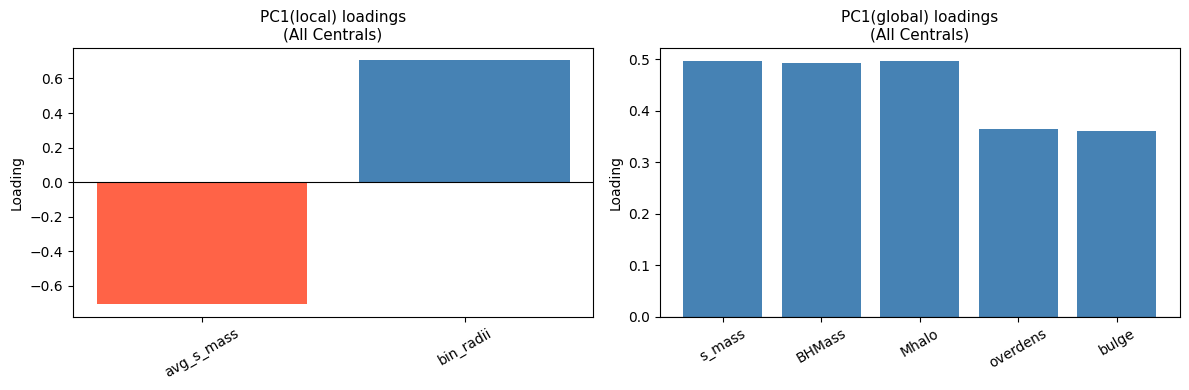

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, key, title in zip(axes,
                          ['load_local', 'load_global'],
                          ['PC1(local) loadings', 'PC1(global) loadings']):
    # Use 'All Centrals' as the reference sample for this plot.
    loadings = all_results['All Centrals'][key]
    colors = ['steelblue' if v >= 0 else 'tomato' for v in loadings.values]
    ax.bar(loadings.index, loadings.values, color=colors)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_title(f'{title}\n(All Centrals)', fontsize=11)
    ax.set_ylabel('Loading')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('pca_loadings_all_centrals.pdf', bbox_inches='tight', dpi=150)
plt.show()

---
## Notes and potential adaptations

1. **Feature lists**: `LOCAL_FEATURES` and `GLOBAL_FEATURES` are defined in Cell 2 and can be edited there. If you add new spatially resolved parameters to your dataset, add them to `LOCAL_FEATURES`; galaxy-wide parameters go into `GLOBAL_FEATURES`.

2. **Green valley exclusion**: Bluck+2020 exclude the ~8% of spaxels in the 'green valley' from the quenching classification analysis. If your `quenching_vector` includes intermediate values, you may want to filter to `quenching_vector.isin([0, 1])` before running.

3. **MC noise scale**: The `noise_scale=0.05` parameter in `compute_theta_mc_error` adds noise at 5% of each variable's std. You can increase this to stress-test the robustness of θ, as Bluck+2020 do in Appendix A.

4. **PC1 sign conventions**: PCA does not fix the sign of the eigenvectors — the sign of PC1 scores is arbitrary and may flip between samples. This does not affect θ (the angle depends only on correlations, not signs), but may affect visual appearance of the hex plots. If the colour gradient runs in the wrong direction visually, you can multiply `pc1_local` or `pc1_global` by −1.

5. **Environmental parameters**: In our dataset `Mhalo` and `overdens` are treated as global parameters (one value per galaxy). Bluck+2020 treat environmental and global parameters as separate groups; if you want to follow that convention exactly, you could define a third `ENVIRONMENTAL_FEATURES = ['Mhalo', 'overdens']` list and compute a separate `PC1(env)`, though Bluck+2020 do not do this for the PCA test itself.


## Investigating high PC(global) outliers


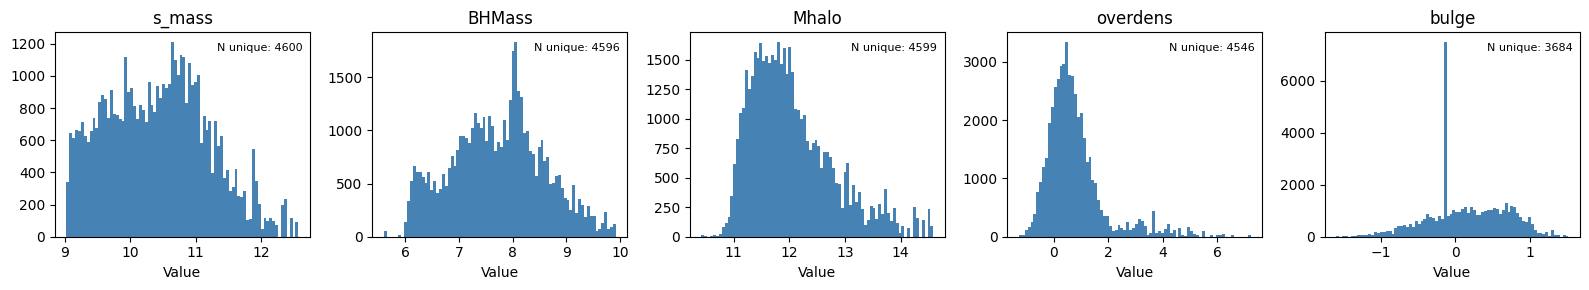

In [17]:
sample_name = 'All Centrals'
df = all_centrals_df

fig, axes = plt.subplots(1, len(GLOBAL_FEATURES), figsize=(16, 3))
for ax, col in zip(axes, GLOBAL_FEATURES):
    ax.hist(df[col].dropna(), bins=80, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel('Value')
    n_unique = df[col].nunique()
    ax.text(0.97, 0.95, f'N unique: {n_unique}',
            transform=ax.transAxes, ha='right', va='top', fontsize=8)
plt.tight_layout()
plt.show()

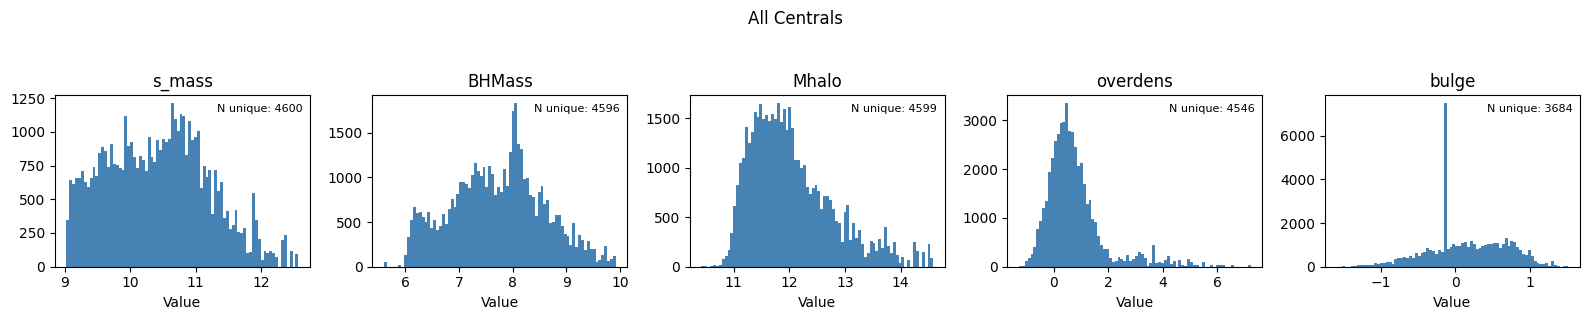

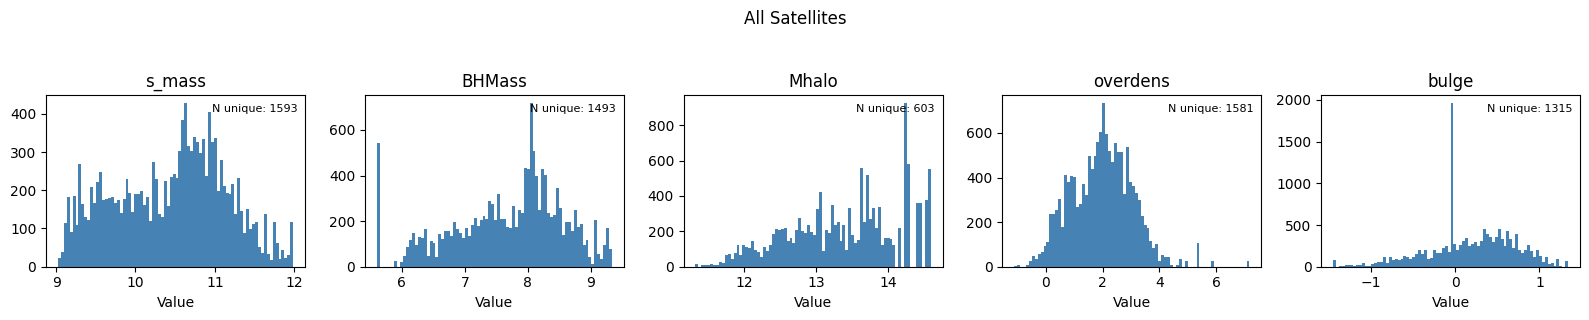

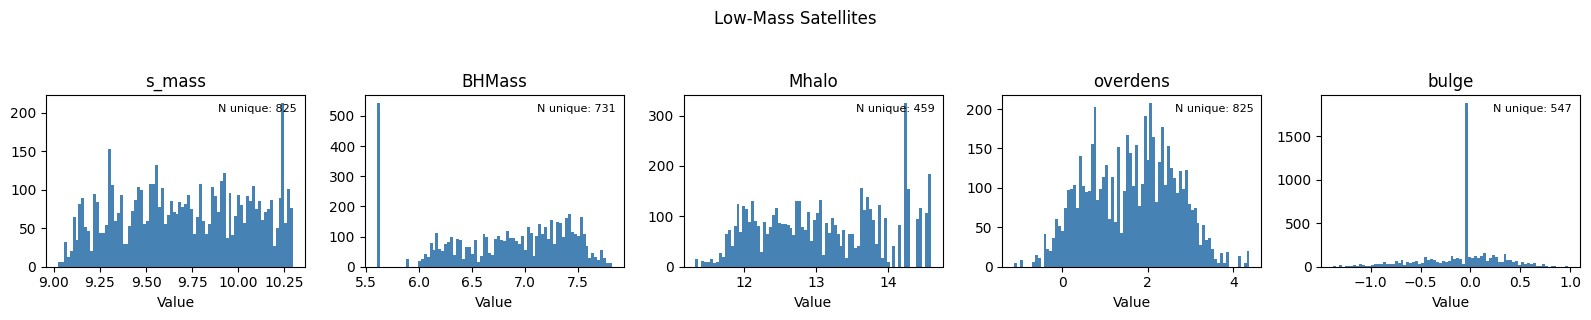

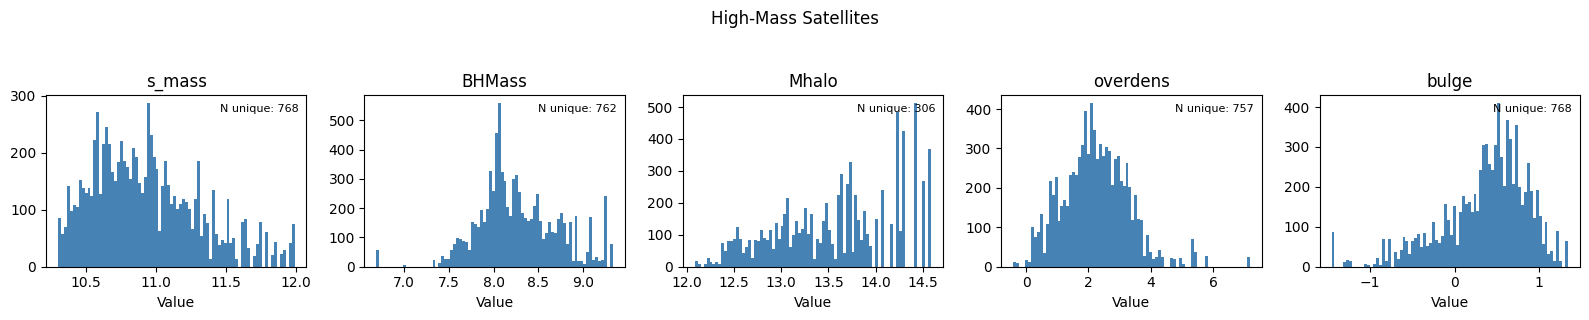

In [18]:
# loop over each sample and plot the global‑feature histograms separately
for sample_name, df in samples.items():
    fig, axes = plt.subplots(1, len(GLOBAL_FEATURES), figsize=(16, 3))
    fig.suptitle(sample_name, fontsize=12, y=1.05)

    for ax, col in zip(axes, GLOBAL_FEATURES):
        vals = df[col].dropna()
        ax.hist(vals, bins=80, color='steelblue', edgecolor='none')
        ax.set_title(col)
        ax.set_xlabel('Value')
        ax.text(0.97, 0.95, f'N unique: {vals.nunique()}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8)

    plt.tight_layout()
    plt.show()

In [19]:
median_bulge = df['bulge'].median()
print(f"Median bulge: {median_bulge:.6f}")

# Print median bulge for each galaxy sample
for sample_name, sample_df in samples.items():
    med = sample_df['bulge'].median()
    print(f"Median bulge ({sample_name}): {med:.6f}")

# Also print median bulge for low-mass centrals
med_low_mass_central = low_mass_central_df['bulge'].median()
print(f"Median bulge (Low-Mass Centrals): {med_low_mass_central:.6f}")

Median bulge: 0.457515
Median bulge (All Centrals): 0.104965
Median bulge (All Satellites): 0.193903
Median bulge (Low-Mass Satellites): -0.044053
Median bulge (High-Mass Satellites): 0.457515
Median bulge (Low-Mass Centrals): -0.134313


In [20]:
for col in GLOBAL_FEATURES:
    vals = df[col].dropna()
    print(f"{col:15s}  min={vals.min():.3f}  max={vals.max():.3f}  "
          f"std={vals.std():.3f}  n_unique={vals.nunique()}")

s_mass           min=10.301  max=11.988  std=0.383  n_unique=768
BHMass           min=6.692  max=9.333  std=0.445  n_unique=762
Mhalo            min=12.086  max=14.590  std=0.634  n_unique=306
overdens         min=-0.420  max=7.180  std=1.069  n_unique=757
bulge            min=-1.454  max=1.342  std=0.512  n_unique=768
